# V9 · 01_2g — Cleaning verification

Visualises the MAD-based outlier cleaner (as used in `01_2e` Section 10
and `01_2f`) so the user can verify what it does per cell.

**Algorithm** (recap):

1. Trusted middle region = cycles $[10..40]$ of the $K{=}50$ context.
2. `med = median(middle)`, `mad = median(|middle - med|)`.
3. Any cycle where $|x - \mathrm{med}| > 5 \cdot \mathrm{mad}$ is
   flagged as an outlier.
4. Outliers replaced by linear interpolation from nearest inliers.
5. Light rolling-median smoothing (win=5) applied to the interpolated series.

**What to look for**:

- Cells with 0 outliers: raw and cleaned should overlap perfectly.
- Cells with edge artefacts (REPT_0034, REPT_0011): cleaned should
  bridge over the initial drop.
- Cells with mid-context artefacts (REPT_0037): cleaned should bridge
  over the drop-and-recover.


## 1. Setup + cleaner

In [1]:
import sys, re
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

PROJ = Path("/home/hj/Desktop/PINNs")
sys.path.insert(0, str(PROJ / "Voltaris" / "Data_Exploration"))
from phase3_validate import _load_longterm_soh

LONGTERM_DIR = PROJ / "Data" / "Longterm"
K = 50
CTX_TAIL = 10
MAD_THRESH = 5.0
TAU = 0.540

def _exp(n, a, b, c): return a * np.exp(-b * n) + c

def clean_context(ctx):
    ctx = np.asarray(ctx, dtype=np.float32).copy()
    n = len(ctx)
    mid_lo, mid_hi = max(5, n//10), min(n - 5, 4 * n // 5)
    mid = ctx[mid_lo:mid_hi]
    if len(mid) < 5:
        return ctx, np.zeros(n, dtype=bool)
    med = float(np.median(mid))
    mad = float(np.median(np.abs(mid - med))) + 1e-6
    is_outlier = np.abs(ctx - med) > MAD_THRESH * mad
    if is_outlier.all() or (~is_outlier).sum() < 2:
        return ctx, is_outlier
    inlier_idx = np.where(~is_outlier)[0]
    for i in np.where(is_outlier)[0]:
        left = inlier_idx[inlier_idx < i]
        right = inlier_idx[inlier_idx > i]
        if len(left) and len(right):
            l, r = left[-1], right[0]
            ctx[i] = ctx[l] + (ctx[r] - ctx[l]) * (i - l) / (r - l)
        elif len(left):
            ctx[i] = ctx[left[-1]]
        else:
            ctx[i] = ctx[right[0]]
    ctx = (pd.Series(ctx).rolling(5, center=True, min_periods=1)
             .median().to_numpy(dtype=np.float32))
    return ctx, is_outlier

def context_holdout_residual(context_soh):
    n_fit = np.arange(K - CTX_TAIL, dtype=float)
    y_fit = np.asarray(context_soh[:K - CTX_TAIL], dtype=float)
    n_val = np.arange(K - CTX_TAIL, K, dtype=float)
    y_val = np.asarray(context_soh[K - CTX_TAIL:K], dtype=float)
    try:
        popt, _ = curve_fit(_exp, n_fit, y_fit,
                            p0=[y_fit[0]-y_fit[-1], 1e-3, y_fit[-1]],
                            maxfev=10000)
        return float(np.sqrt(np.mean((_exp(n_val, *popt) - y_val)**2)) * 100)
    except Exception:
        return float("nan")

# Discover cells
_pat = re.compile(r"^(?P<make>[A-Za-z]+)_Longterm_cell_(?P<cell_id>\d+)(?:_[A-Za-z]+)?\.csv$")
records = []
_seen = set()
for p in sorted(LONGTERM_DIR.glob("*.csv")):
    m = _pat.match(p.name)
    if not m: continue
    mk, cid = m.group("make"), m.group("cell_id")
    key = (mk, cid)
    if key in _seen: continue
    _seen.add(key)
    try:
        obs_n, obs_soh = _load_longterm_soh(cid, mk)
    except Exception:
        continue
    if len(obs_soh) < K: continue
    ctx_raw = obs_soh[:K].astype(np.float32)
    ctx_cln, is_out = clean_context(ctx_raw)
    r_raw = context_holdout_residual(ctx_raw)
    r_cln = context_holdout_residual(ctx_cln)
    if not np.isfinite(r_raw) or not np.isfinite(r_cln): continue
    records.append({
        "cell": f"{mk}_{cid}", "make": mk, "cell_id": cid,
        "n_outliers": int(is_out.sum()),
        "residual_raw": r_raw,
        "residual_clean": r_cln,
        "delta": r_cln - r_raw,
    })
df = pd.DataFrame(records).sort_values(["make","cell"]).reset_index(drop=True)
print(f"cells: {len(df)}")
print(f"cells with >=1 detected outlier: {(df['n_outliers']>0).sum()}")
print(f"cells with 0 outliers: {(df['n_outliers']==0).sum()}")


/tmp/ipykernel_65630/3594446350.py:18: RuntimeWarning: overflow encountered in exp
  def _exp(n, a, b, c): return a * np.exp(-b * n) + c


cells: 59
cells with >=1 detected outlier: 32
cells with 0 outliers: 27


## 2. Cells with the biggest cleaning impact

In [2]:
df.assign(abs_delta=df['delta'].abs()) \
  .nlargest(10, 'abs_delta') \
  [['cell','make','n_outliers','residual_raw','residual_clean','delta']]


,cell,make,n_outliers,residual_raw,residual_clean,delta
44,REPT_0034,REPT,8,6.275632,0.050402,-6.225230
38,REPT_0011,REPT,2,4.034659,0.116377,-3.918282
45,REPT_0037,REPT,5,2.333735,0.413018,-1.920717
43,REPT_0032,REPT,7,0.964807,0.145557,-0.819251
19,CALB_0020,CALB,8,0.722526,0.362190,-0.360336
29,EVE_0003,EVE,2,0.707057,0.417061,-0.289996
11,CALB_0012,CALB,6,0.511764,0.296356,-0.215408
17,CALB_0018,CALB,2,0.339891,0.128001,-0.211891
2,CALB_0003,CALB,8,0.289629,0.094780,-0.194849
31,EVE_0005,EVE,3,0.151193,0.015079,-0.136114


## 3. Per-cell raw vs cleaned context — individual plots

One figure per cell. Blue = raw K=50 context; orange = cleaned; red
crosses mark cycles flagged as outliers.

Rendering 59 per-cell cleaning-verification figures (highest-impact first)...



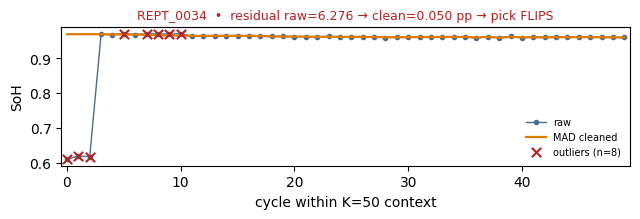

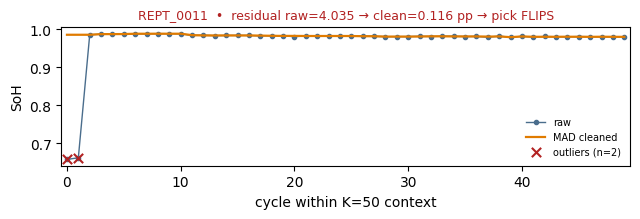

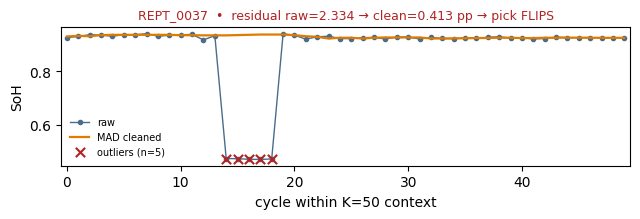

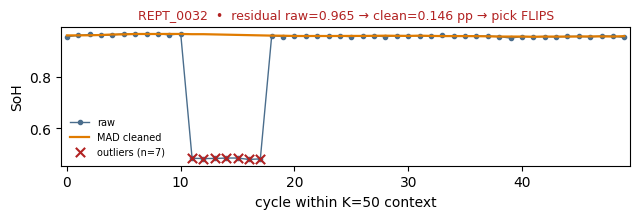

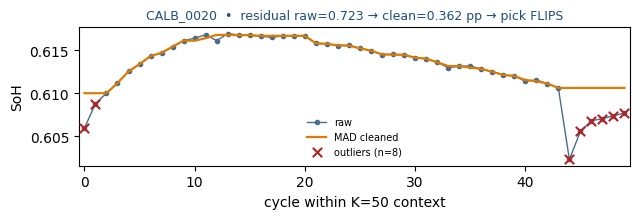

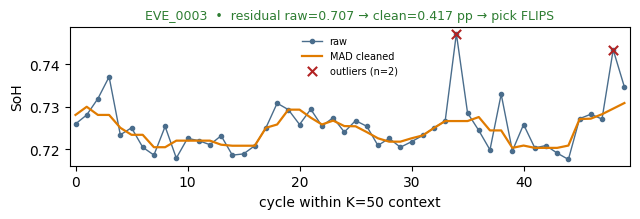

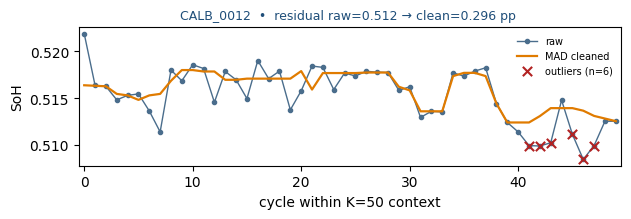

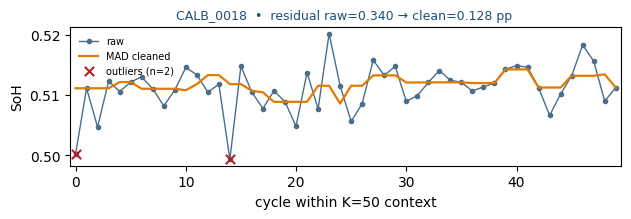

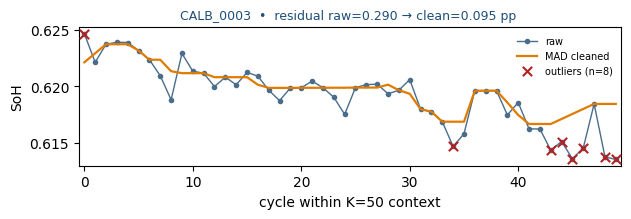

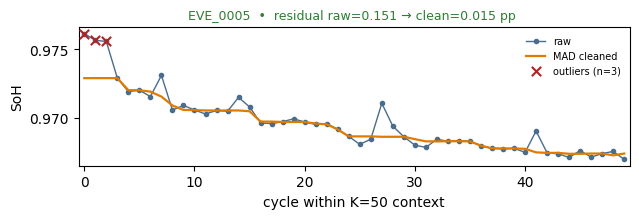

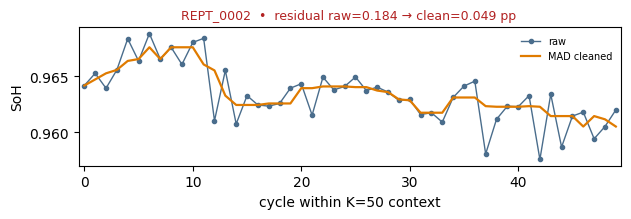

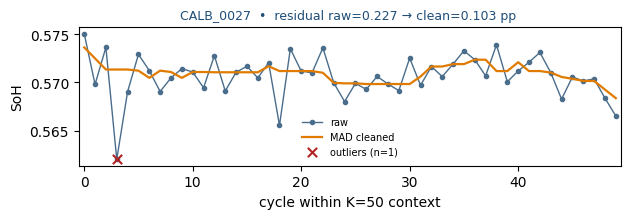

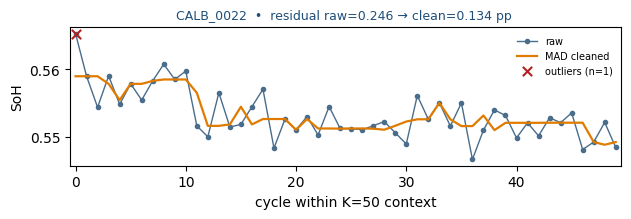

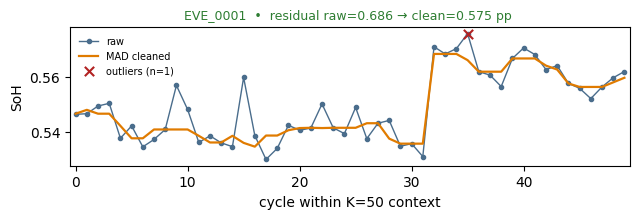

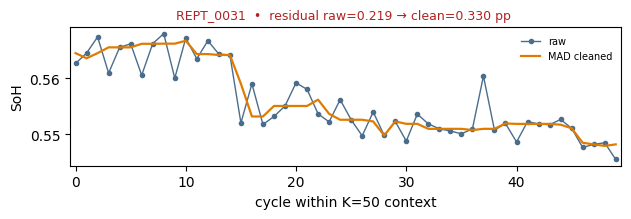

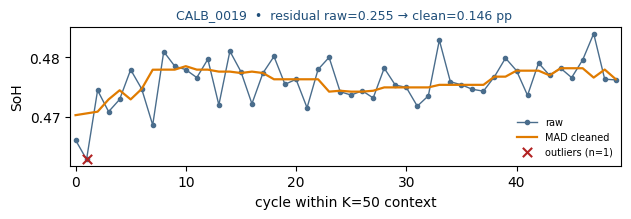

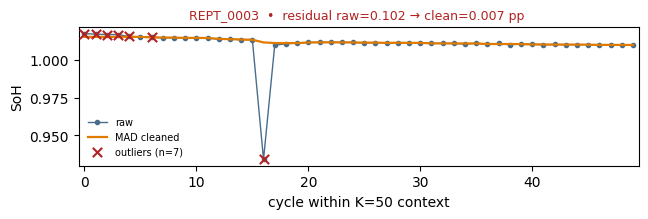

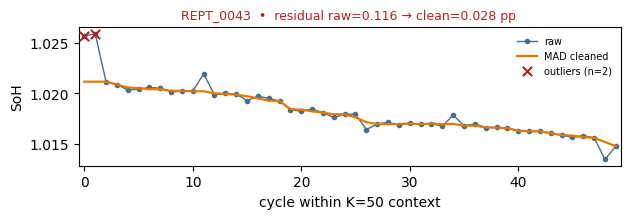

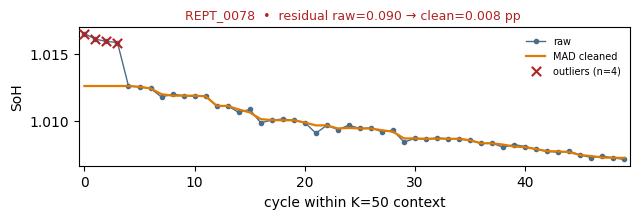

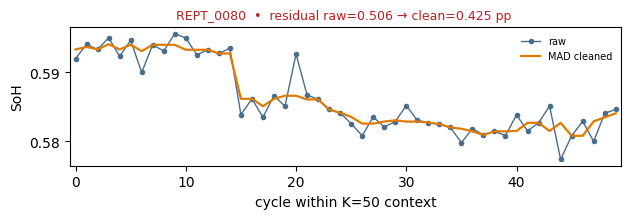

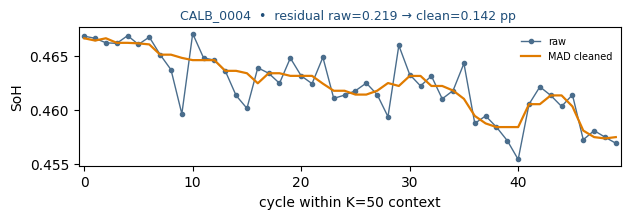

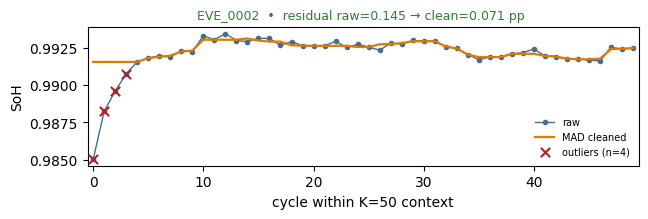

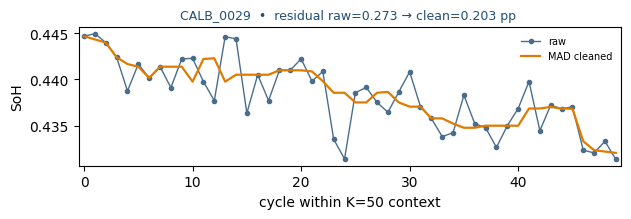

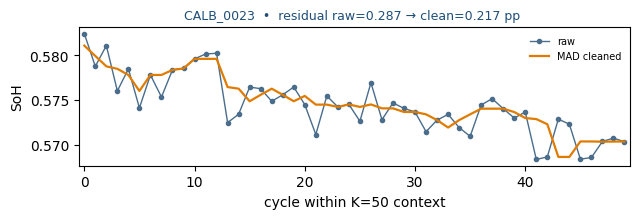

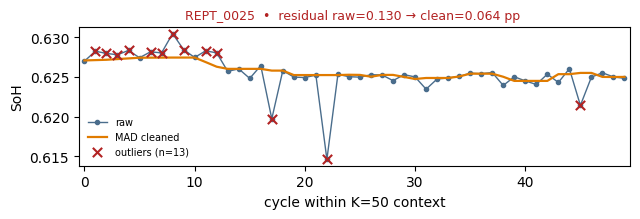

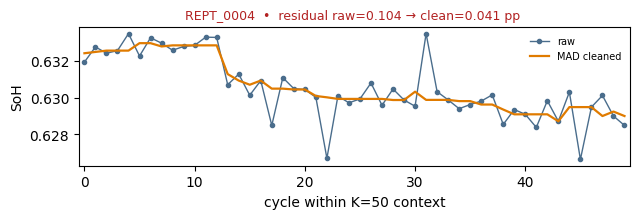

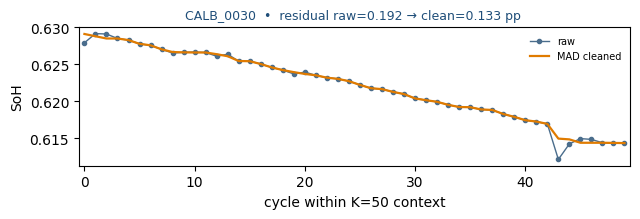

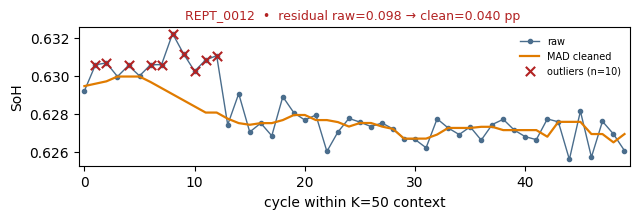

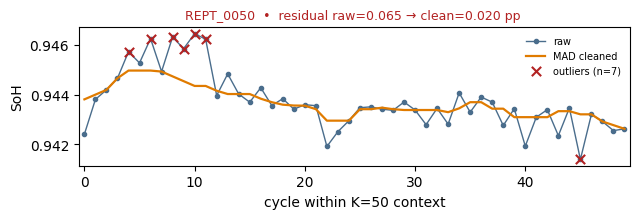

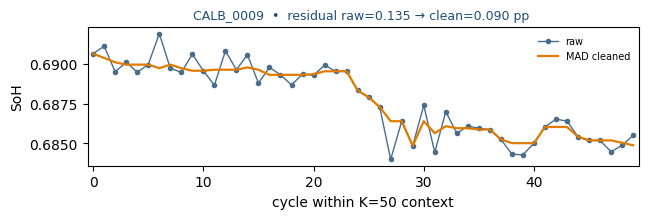

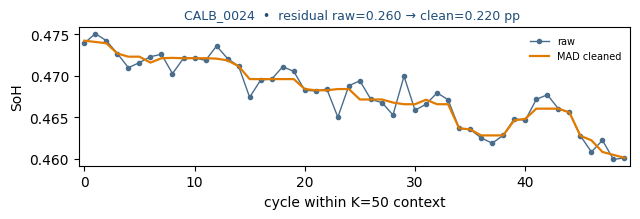

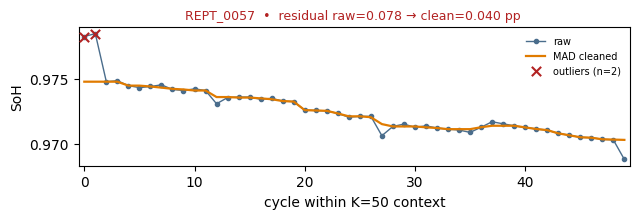

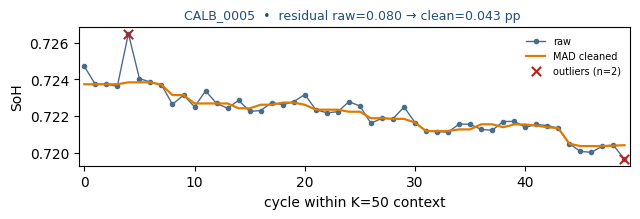

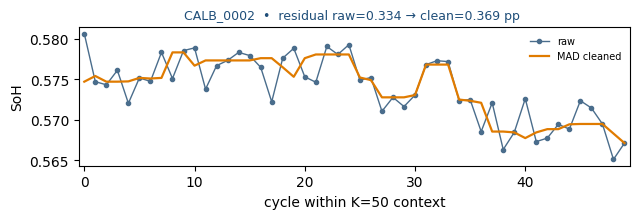

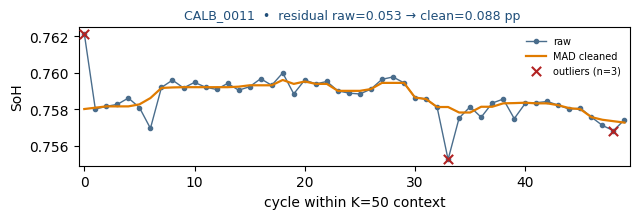

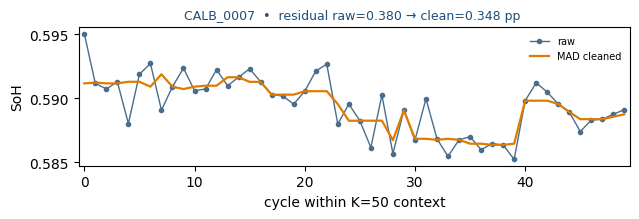

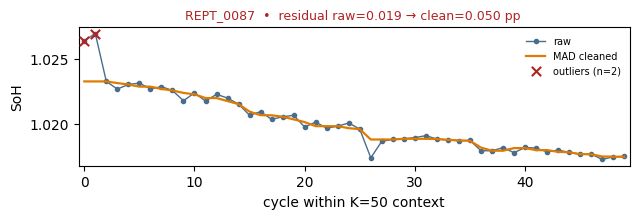

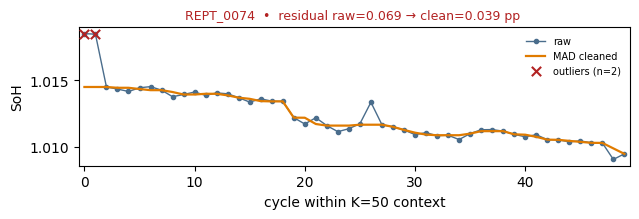

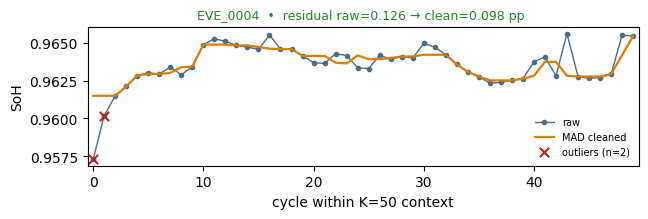

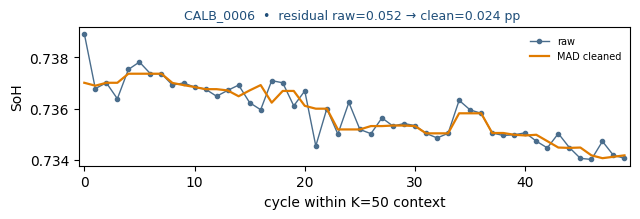

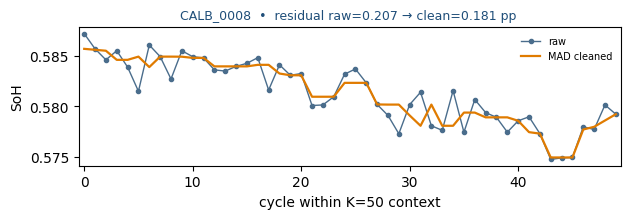

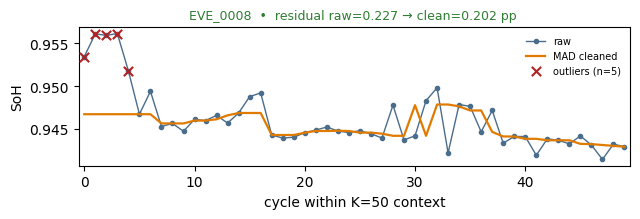

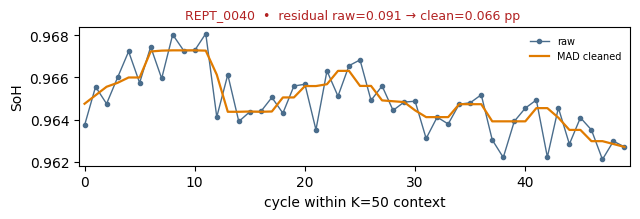

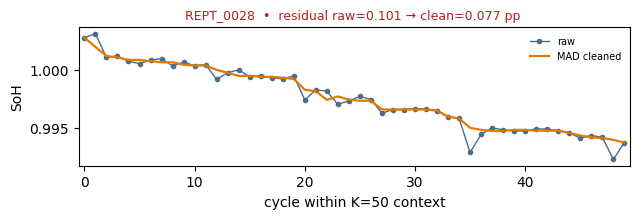

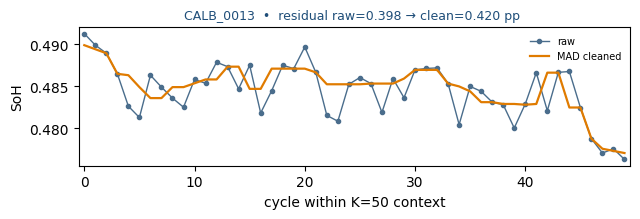

/tmp/ipykernel_65630/3594446350.py:18: RuntimeWarning: overflow encountered in exp
  def _exp(n, a, b, c): return a * np.exp(-b * n) + c


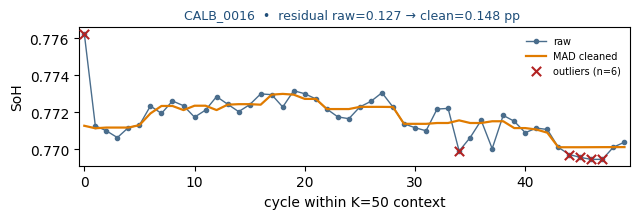

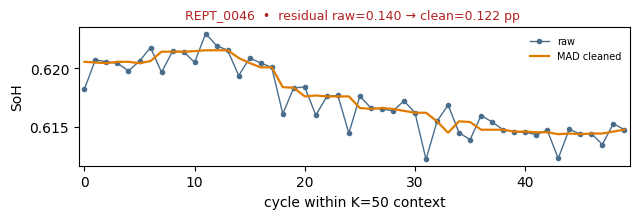

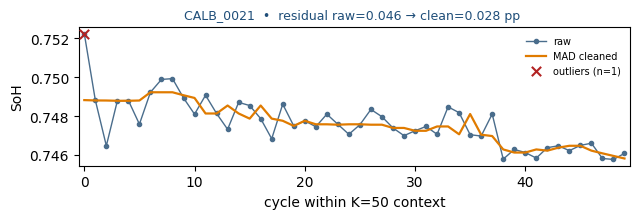

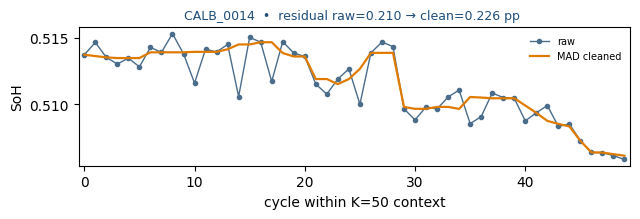

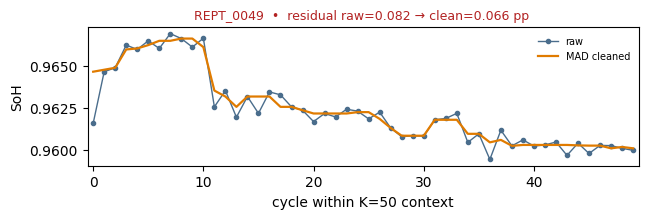

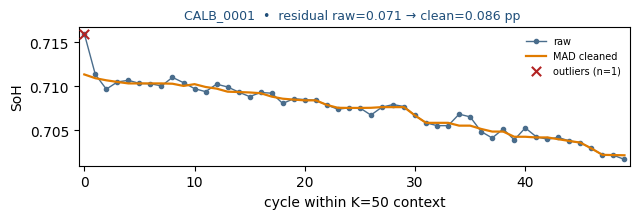

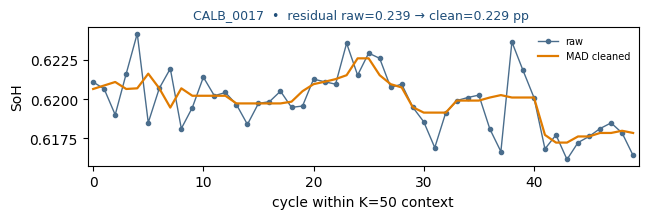

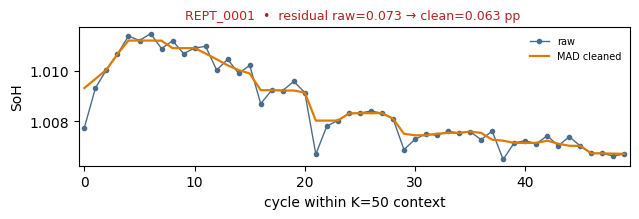

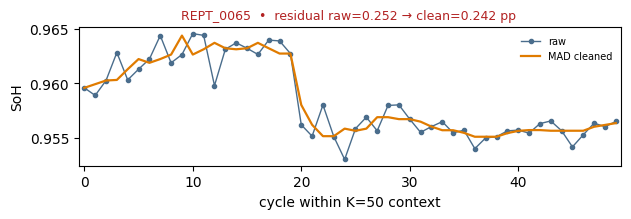

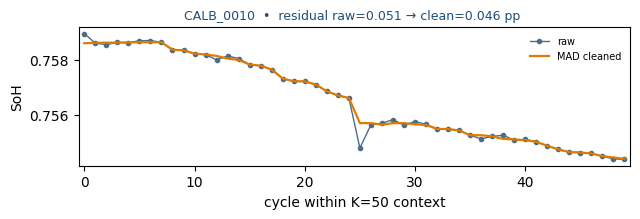

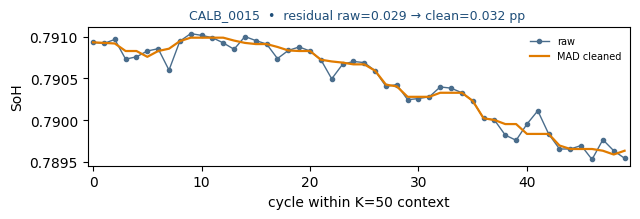

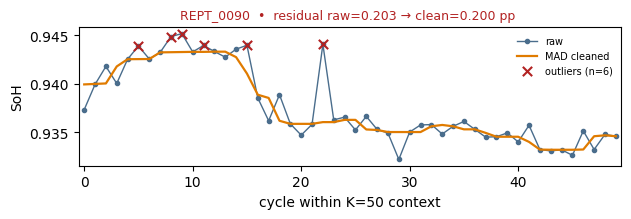

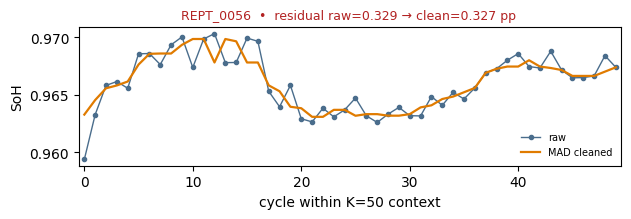

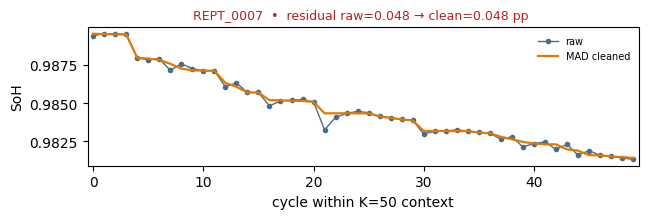


All figures saved to /home/hj/Desktop/PINNs/outputs/results/cleaning_verification/


In [3]:
SUP_COLOR = {"CALB":"#1F4E79","EVE":"#2E7D32","REPT":"#B22222"}
per_cell_dir = PROJ / "outputs/results/cleaning_verification"
per_cell_dir.mkdir(parents=True, exist_ok=True)

def _plot_one(row):
    cid, mk = row["cell_id"], row["make"]
    obs_n, obs_soh = _load_longterm_soh(cid, mk)
    ctx_raw = obs_soh[:K].astype(np.float32)
    ctx_cln, is_out = clean_context(ctx_raw)
    r_raw = context_holdout_residual(ctx_raw)
    r_cln = context_holdout_residual(ctx_cln)
    fig, ax = plt.subplots(figsize=(6.5, 2.3))
    x = np.arange(K)
    ax.plot(x, ctx_raw, color="#4A6D8C", lw=1.0, marker="o", ms=3,
             label="raw", zorder=3)
    ax.plot(x, ctx_cln, color="#E07B00", lw=1.6, label="MAD cleaned", zorder=4)
    if is_out.any():
        ax.scatter(x[is_out], ctx_raw[is_out], color="#B22222",
                    marker="x", s=45, zorder=5,
                    label=f"outliers (n={int(is_out.sum())})")
    ax.set_xlim(-0.5, K - 0.5)
    ax.set_xlabel("cycle within K=50 context")
    ax.set_ylabel("SoH")
    pick_change = ("→ pick FLIPS" if (r_raw >= TAU) != (r_cln >= TAU) else "")
    title = (f"{row['cell']}  •  residual raw={r_raw:.3f} → clean={r_cln:.3f} pp "
             f"{pick_change}")
    ax.set_title(title, fontsize=9, color=SUP_COLOR[mk])
    ax.legend(fontsize=7, loc="best", frameon=False)
    fig.tight_layout()
    fig.savefig(per_cell_dir / f"{row['cell']}.pdf", dpi=180,
                 bbox_inches="tight")
    plt.show()
    plt.close(fig)

# Highest-impact first, then rest by supplier
sorted_df = df.assign(abs_delta=df['delta'].abs()) \
              .sort_values(['abs_delta'], ascending=False)
print(f"Rendering {len(sorted_df)} per-cell cleaning-verification figures "
      f"(highest-impact first)...\n")
for _, r in sorted_df.iterrows():
    _plot_one(r)
print(f"\nAll figures saved to {per_cell_dir}/")


## 4. Summary distribution

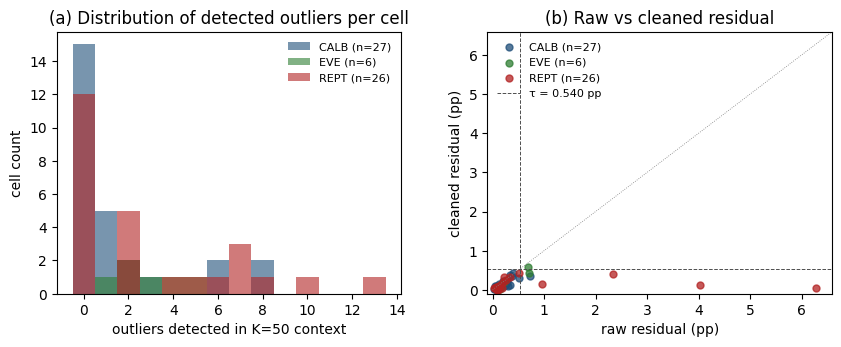

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.4),
    gridspec_kw=dict(wspace=0.25))
# (A) outlier counts
for mk in ["CALB","EVE","REPT"]:
    vals = df.loc[df["make"] == mk, "n_outliers"].values
    if len(vals):
        ax1.hist(vals, bins=np.arange(vals.max()+2)-0.5,
                  alpha=0.6, label=f"{mk} (n={len(vals)})",
                  color=SUP_COLOR[mk])
ax1.set_xlabel("outliers detected in K=50 context")
ax1.set_ylabel("cell count")
ax1.set_title("(a) Distribution of detected outliers per cell")
ax1.legend(fontsize=8, frameon=False)

# (B) residual before/after
for mk in ["CALB","EVE","REPT"]:
    sub = df[df["make"] == mk]
    ax2.scatter(sub["residual_raw"], sub["residual_clean"],
                 color=SUP_COLOR[mk], s=25, alpha=0.75,
                 label=f"{mk} (n={len(sub)})")
lim = max(df["residual_raw"].max(), df["residual_clean"].max()) * 1.05
ax2.plot([0, lim],[0, lim], color="0.5", lw=0.6, ls=":")
ax2.axvline(TAU, color="0.3", lw=0.7, ls="--", label=f"τ = {TAU:.3f} pp")
ax2.axhline(TAU, color="0.3", lw=0.7, ls="--")
ax2.set_xlabel("raw residual (pp)")
ax2.set_ylabel("cleaned residual (pp)")
ax2.set_title("(b) Raw vs cleaned residual")
ax2.set_xlim(-0.1, lim); ax2.set_ylim(-0.1, lim)
ax2.legend(fontsize=8, frameon=False, loc="upper left")
fig.savefig(PROJ / "outputs/results/cleaning_verification_summary.pdf",
             dpi=200, bbox_inches="tight")
plt.show()
